# 13 · Tablas, figuras y resumen para el manuscrito — Bogotá 2023

**Objetivo.** Congelar la salida analítica validada de las Compuertas 11–13 en tablas y figuras reproducibles para el artículo. Esta libreta **no reestima modelos** ni selecciona resultados según significancia.

La salida distingue siempre los estimandos **Bogotá–Región** y **Bogotá D. C. interno**, presenta intervalos simultáneos y separa las contribuciones residencial y del kernel de movilidad.


In [16]:
%pip -q install pandas numpy matplotlib seaborn


In [17]:
from pathlib import Path
from datetime import datetime, timezone
import json, os, shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("/content/colombia-stochastic-access")
OUT = ROOT / "outputs/bogota_em2023/gate14"
DRIVE_BASE = Path("/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023")
OUT.mkdir(parents=True, exist_ok=True)
PAPER_FIGURES = ROOT / "paper/figures"
PAPER_FIGURES.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Entorno fuera de Colab o Drive no montado: {exc}")

G11 = Path(os.environ.get("GATE11_DIR_OVERRIDE", DRIVE_BASE / "results/gate11"))
G12 = Path(os.environ.get("GATE12_DIR_OVERRIDE", DRIVE_BASE / "results/gate12"))
G13 = Path(os.environ.get("GATE13_DIR_OVERRIDE", DRIVE_BASE / "results/gate13"))
paths = {
    "gate11": G11 / "gate_11.json", "gate12": G12 / "gate_12.json", "gate13": G13 / "gate_13.json",
    "scope_intervals": G12 / "scope_comparison_intervals.csv",
    "scope_points": G12 / "scope_comparison_point_estimates.csv",
    "city_support": G12 / "bogota_dc_internal_scope_support.csv",
    "city_targets": G12 / "bogota_dc_internal_target_summary.csv",
    "municipal": G12 / "region_municipality_origin_contributions.csv",
    "paired_intervals": G13 / "paired_scope_contrast_intervals.csv",
    "paired_points": G13 / "paired_scope_contrasts_point.csv",
    "stratum": G11 / "final_stratum_spearman_intervals.csv",
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing: raise FileNotFoundError("Faltan resultados validados: " + ", ".join(missing))
gates = {number: json.loads(paths[f"gate{number}"].read_text(encoding="utf-8")) for number in (11, 12, 13)}
for number, report in gates.items():
    if not report.get("gate", {}).get(f"gate_{number}_passed", False): raise RuntimeError(f"Compuerta {number} no aprobada")
print("Insumos validados: Compuertas 11, 12 y 13")
print("Salida:", OUT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Insumos validados: Compuertas 11, 12 y 13
Salida: /content/colombia-stochastic-access/outputs/bogota_em2023/gate14


In [18]:
scope_intervals = pd.read_csv(paths["scope_intervals"])
scope_points = pd.read_csv(paths["scope_points"])
paired_intervals = pd.read_csv(paths["paired_intervals"])
paired_points = pd.read_csv(paths["paired_points"])
municipal = pd.read_csv(paths["municipal"])
city_support = pd.read_csv(paths["city_support"])
city_targets = pd.read_csv(paths["city_targets"])
stratum = pd.read_csv(paths["stratum"])

scope_labels = {"bogota_region": "Bogotá–Región", "bogota_dc_internal": "Bogotá D. C. interno"}
purpose_labels = {"employment": "Empleo", "education": "Educación", "health": "Salud"}

def interval_lookup(frame, scope, purpose, effect):
    row = frame[frame["scope"].eq(scope) & frame["purpose_group"].eq(purpose) & frame["effect"].eq(effect)]
    if len(row) != 1: raise RuntimeError(f"Intervalo no único: {scope}/{purpose}/{effect}")
    return row.iloc[0]

main_rows = []
for scope in scope_labels:
    for purpose in purpose_labels:
        total = interval_lookup(scope_intervals, scope, purpose, "female_minus_male_total")
        residence = interval_lookup(scope_intervals, scope, purpose, "residential_contribution")
        kernel = interval_lookup(scope_intervals, scope, purpose, "kernel_contribution")
        main_rows.append({
            "scope": scope_labels[scope], "purpose": purpose_labels[purpose],
            "female_minus_male_gap": total.point_estimate,
            "gap_simultaneous_ci_lower": total.simultaneous_ci_lower,
            "gap_simultaneous_ci_upper": total.simultaneous_ci_upper,
            "residential_contribution": residence.point_estimate,
            "residential_simultaneous_ci_lower": residence.simultaneous_ci_lower,
            "residential_simultaneous_ci_upper": residence.simultaneous_ci_upper,
            "kernel_contribution": kernel.point_estimate,
            "kernel_simultaneous_ci_lower": kernel.simultaneous_ci_lower,
            "kernel_simultaneous_ci_upper": kernel.simultaneous_ci_upper,
        })
table_main = pd.DataFrame(main_rows)
table_main.to_csv(OUT / "table_1_main_scope_sex_gaps.csv", index=False)
table_main.to_latex(OUT / "table_1_main_scope_sex_gaps.tex", index=False, float_format="%.3f")
display(table_main.round(3))


,scope,purpose,female_minus_male_gap,gap_simultaneous_ci_lower,gap_simultaneous_ci_upper,residential_contribution,residential_simultaneous_ci_lower,residential_simultaneous_ci_upper,kernel_contribution,kernel_simultaneous_ci_lower,kernel_simultaneous_ci_upper
0,Bogotá–Región,Empleo,0.999,0.632,1.366,-0.033,-0.088,0.023,1.031,0.671,1.392
1,Bogotá–Región,Educación,0.827,0.451,1.204,-0.013,-0.067,0.042,0.840,0.467,1.213
2,Bogotá–Región,Salud,0.705,0.252,1.159,-0.031,-0.096,0.035,0.736,0.294,1.178
3,Bogotá D. C. interno,Empleo,0.479,0.289,0.669,-0.010,-0.024,0.003,0.489,0.295,0.684
4,Bogotá D. C. interno,Educación,0.399,0.173,0.624,0.010,-0.010,0.030,0.389,0.160,0.618
5,Bogotá D. C. interno,Salud,0.240,-0.046,0.527,-0.001,-0.014,0.012,0.242,-0.052,0.535


In [19]:
paired_effect_names = {
    "region_minus_city__female_minus_male_total": "Brecha total",
    "region_minus_city__residential_contribution": "Componente residencial",
    "region_minus_city__kernel_contribution": "Componente del kernel",
    "relative_attenuation": "Reducción relativa al restringir a Bogotá D. C.",
}
table_amplification = paired_intervals.copy()
table_amplification["purpose"] = table_amplification["purpose_group"].map(purpose_labels)
table_amplification["estimand"] = table_amplification["effect"].map(paired_effect_names)
table_amplification = table_amplification[[
    "purpose", "estimand", "point_estimate", "bootstrap_sd",
    "simultaneous_ci_lower", "simultaneous_ci_upper", "simultaneously_positive",
]]
table_amplification.to_csv(OUT / "table_2_paired_scope_amplification.csv", index=False)
table_amplification.to_latex(OUT / "table_2_paired_scope_amplification.tex", index=False, float_format="%.3f")

external = municipal[municipal["municipality"].astype(str).str.upper().ne("BOGOTA")].copy()
region_kernel = scope_points[scope_points["scope"].eq("bogota_region")].set_index("purpose_group")["kernel_contribution"]
external["share_of_regional_kernel"] = external.apply(
    lambda row: row["kernel_contribution"] / region_kernel[row["purpose_group"]], axis=1
)
external["absolute_kernel"] = external["kernel_contribution"].abs()
top_external = external.sort_values(["purpose_group", "absolute_kernel"], ascending=[True, False]).groupby(
    "purpose_group", observed=True
).head(8).copy()
top_external["purpose"] = top_external["purpose_group"].map(purpose_labels)
top_external = top_external[["purpose", "municipality", "kernel_contribution", "share_of_regional_kernel",
                             "female_residential_probability", "male_residential_probability"]]
top_external.to_csv(OUT / "table_3_top_external_municipality_contributions.csv", index=False)
top_external.to_latex(OUT / "table_3_top_external_municipality_contributions.tex", index=False, float_format="%.3f")
display(table_amplification.round(3))
display(top_external.round(3))


,purpose,estimand,point_estimate,bootstrap_sd,simultaneous_ci_lower,simultaneous_ci_upper,simultaneously_positive
0,Empleo,Brecha total,0.520,0.153,0.178,0.861,True
1,Empleo,Componente residencial,-0.022,0.025,-0.078,0.034,False
2,Empleo,Componente del kernel,0.542,0.146,0.217,0.866,True
3,Empleo,Reducción relativa al restringir a Bogotá D. C.,0.520,0.088,0.318,0.722,True
4,Educación,Brecha total,0.429,0.160,0.070,0.787,True
5,Educación,Componente residencial,-0.022,0.024,-0.076,0.031,False
6,Educación,Componente del kernel,0.451,0.155,0.108,0.794,True
7,Educación,Reducción relativa al restringir a Bogotá D. C.,0.518,0.112,0.261,0.776,True
8,Salud,Brecha total,0.465,0.169,0.087,0.843,True
9,Salud,Componente residencial,-0.030,0.028,-0.091,0.032,False


,purpose,municipality,kernel_contribution,share_of_regional_kernel,female_residential_probability,male_residential_probability
8,Educación,FACATATIVA,0.308,0.367,0.024,0.025
13,Educación,MOSQUERA,0.059,0.070,0.024,0.025
9,Educación,FUNZA,0.047,0.056,0.017,0.017
7,Educación,EL ROSAL,0.021,0.024,0.004,0.004
3,Educación,CAJICA,0.013,0.016,0.011,0.011
2,Educación,BOJACA,0.011,0.013,0.001,0.002
11,Educación,LA CALERA,0.011,0.013,0.003,0.003
15,Educación,SOACHA,-0.010,-0.012,0.040,0.042
30,Empleo,FACATATIVA,0.223,0.216,0.021,0.021
37,Empleo,SOACHA,0.204,0.198,0.106,0.107


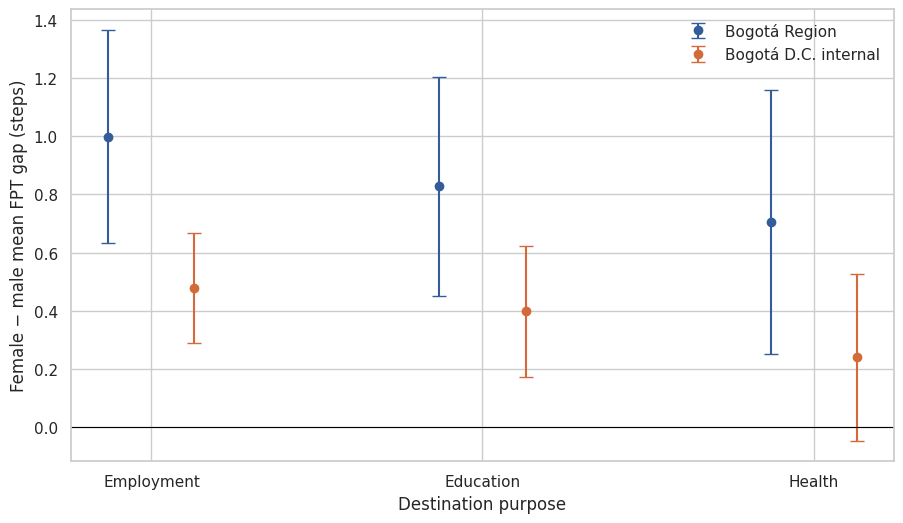

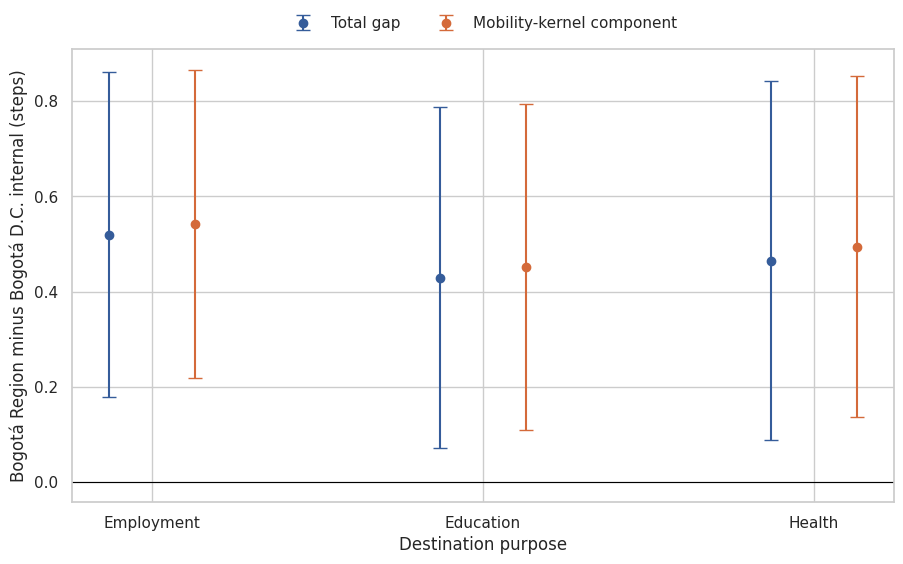

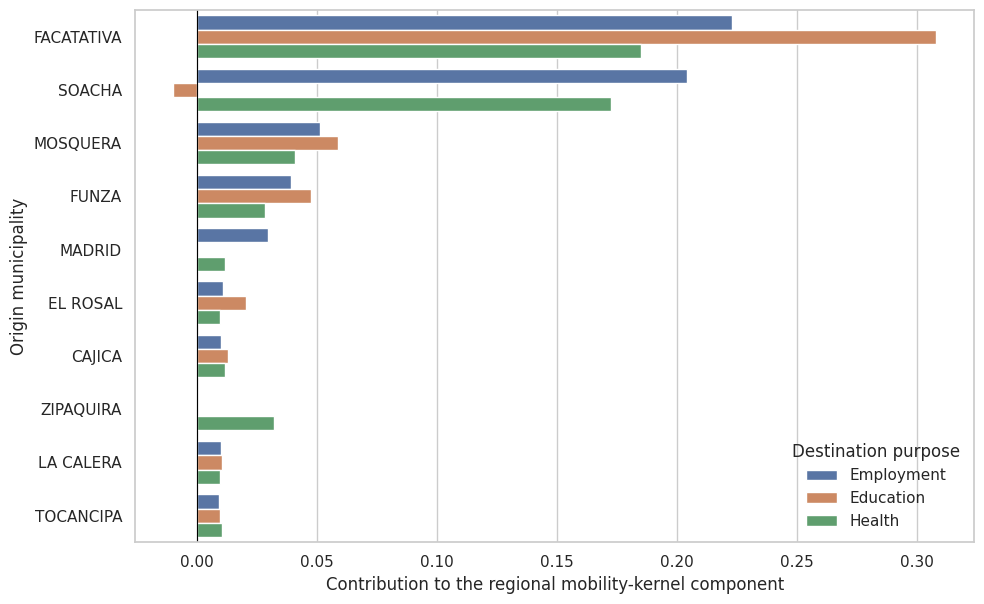

In [20]:
sns.set_theme(style="whitegrid", context="notebook")
purpose_order = ["Empleo", "Educación", "Salud"]
purpose_tick_labels = ["Employment", "Education", "Health"]

# Figure 1: scope-specific gender gaps
fig, axis = plt.subplots(figsize=(9.2, 5.4))
colors = {"Bogotá–Región": "#355C9A", "Bogotá D. C. interno": "#D46A3A"}
scope_plot_labels = {"Bogotá–Región": "Bogotá Region", "Bogotá D. C. interno": "Bogotá D.C. internal"}
for offset, scope in zip((-0.13, 0.13), scope_labels.values()):
    frame = table_main[table_main["scope"].eq(scope)].set_index("purpose").reindex(purpose_order)
    y = frame["female_minus_male_gap"].to_numpy(float)
    x = np.arange(3) + offset
    axis.errorbar(
        x, y,
        yerr=[
            y - frame["gap_simultaneous_ci_lower"].to_numpy(float),
            frame["gap_simultaneous_ci_upper"].to_numpy(float) - y,
        ],
        fmt="o", capsize=5, color=colors[scope], label=scope_plot_labels[scope],
    )
axis.axhline(0, color="black", linewidth=.8)
axis.set_xticks(np.arange(3))
axis.set_xticklabels(purpose_tick_labels)
axis.set(
    xlabel="Destination purpose",
    ylabel="Female − male mean FPT gap (steps)",
)
axis.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(OUT / "figure_1_scope_sex_gaps.png", dpi=300, bbox_inches="tight")
fig.savefig(PAPER_FIGURES / "figure_1_scope_sex_gaps.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: paired scope amplification
effects_plot = table_amplification[
    table_amplification["estimand"].isin(["Brecha total", "Componente del kernel"])
].copy()
fig, axis = plt.subplots(figsize=(9.2, 5.8))
for offset, estimand, label, color in [
    (-0.13, "Brecha total", "Total gap", "#355C9A"),
    (0.13, "Componente del kernel", "Mobility-kernel component", "#D46A3A"),
]:
    frame = effects_plot[effects_plot["estimand"].eq(estimand)].set_index("purpose").reindex(purpose_order)
    y = frame["point_estimate"].to_numpy(float)
    x = np.arange(3) + offset
    axis.errorbar(
        x, y,
        yerr=[
            y - frame["simultaneous_ci_lower"].to_numpy(float),
            frame["simultaneous_ci_upper"].to_numpy(float) - y,
        ],
        fmt="o", capsize=5, color=color, label=label,
    )
axis.axhline(0, color="black", linewidth=.8)
axis.set_xticks(np.arange(3))
axis.set_xticklabels(purpose_tick_labels)
axis.set(
    xlabel="Destination purpose",
    ylabel="Bogotá Region minus Bogotá D.C. internal (steps)",
)
axis.legend(
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
)
fig.tight_layout()
fig.savefig(OUT / "figure_2_paired_scope_amplification.png", dpi=300, bbox_inches="tight")
fig.savefig(PAPER_FIGURES / "figure_2_paired_scope_amplification.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: external-municipality kernel contributions
ranking = external.groupby("municipality", observed=True)["absolute_kernel"].sum().nlargest(10).index
plot_external = external[external["municipality"].isin(ranking)].copy()
purpose_plot_labels = {"employment": "Employment", "education": "Education", "health": "Health"}
plot_external["purpose_plot"] = plot_external["purpose_group"].map(purpose_plot_labels)
fig, axis = plt.subplots(figsize=(10, 6.2))
sns.barplot(
    data=plot_external,
    y="municipality",
    x="kernel_contribution",
    hue="purpose_plot",
    hue_order=["Employment", "Education", "Health"],
    order=list(ranking),
    orient="h",
    ax=axis,
)
axis.axvline(0, color="black", linewidth=.8)
axis.set(
    xlabel="Contribution to the regional mobility-kernel component",
    ylabel="Origin municipality",
)
axis.legend(title="Destination purpose", frameon=False)
fig.tight_layout()
fig.savefig(OUT / "figure_3_external_municipality_kernel_contributions.png", dpi=300, bbox_inches="tight")
fig.savefig(PAPER_FIGURES / "figure_3_external_municipality_kernel_contributions.png", dpi=300, bbox_inches="tight")
plt.show()


In [21]:
gap_contrasts = paired_intervals[paired_intervals["effect"].eq("region_minus_city__female_minus_male_total")].set_index("purpose_group")
kernel_contrasts = paired_intervals[paired_intervals["effect"].eq("region_minus_city__kernel_contribution")].set_index("purpose_group")
attenuation = paired_intervals[paired_intervals["effect"].eq("relative_attenuation")].set_index("purpose_group")

lines = [
    "# Frozen analytical summary — Bogotá EODH 2023", "",
    "All estimates use the validated core-50, outside-target, tau=20 specification. Intervals reported below are simultaneous within each three-destination family.", "",
    "## Main scope finding", "",
]
for purpose in ("employment", "education", "health"):
    row = gap_contrasts.loc[purpose]; att = attenuation.loc[purpose]
    lines.append(
        f"- {purpose_labels[purpose]}: the Bogotá–Region female-minus-male gap exceeds the Bogotá D.C.-internal gap by "
        f"{row.point_estimate:.3f} steps (simultaneous 95% CI {row.simultaneous_ci_lower:.3f}, {row.simultaneous_ci_upper:.3f}); "
        f"restricting the scope attenuates the point estimate by {100*att.point_estimate:.1f}%."
    )
lines += ["", "## Mechanism", "",
          "The paired residential contrasts include zero for all three destinations, whereas the paired kernel contrasts are positive with simultaneous intervals above zero. The territorial amplification is therefore associated with the estimated mobility kernel rather than the residential-start composition.", "",
          "## Interpretation boundary", "",
          "These are contrasts between two descriptive stochastic-accessibility estimands with different networks and scope-specific opportunity sets. They do not identify a causal effect of municipal boundaries or of removing peripheral municipalities."]
(OUT / "frozen_results_summary.md").write_text("\n".join(lines), encoding="utf-8")
print((OUT / "frozen_results_summary.md").read_text(encoding="utf-8"))


# Frozen analytical summary — Bogotá EODH 2023

All estimates use the validated core-50, outside-target, tau=20 specification. Intervals reported below are simultaneous within each three-destination family.

## Main scope finding

- Empleo: the Bogotá–Region female-minus-male gap exceeds the Bogotá D.C.-internal gap by 0.520 steps (simultaneous 95% CI 0.178, 0.861); restricting the scope attenuates the point estimate by 52.0%.
- Educación: the Bogotá–Region female-minus-male gap exceeds the Bogotá D.C.-internal gap by 0.429 steps (simultaneous 95% CI 0.070, 0.787); restricting the scope attenuates the point estimate by 51.8%.
- Salud: the Bogotá–Region female-minus-male gap exceeds the Bogotá D.C.-internal gap by 0.465 steps (simultaneous 95% CI 0.087, 0.843); restricting the scope attenuates the point estimate by 65.9%.

## Mechanism

The paired residential contrasts include zero for all three destinations, whereas the paired kernel contrasts are positive with simultaneous intervals a

In [22]:
checks = {
    "gate11_dependency_valid": True, "gate12_dependency_valid": True, "gate13_dependency_valid": True,
    "main_table_complete": bool(len(table_main) == 6 and table_main.notna().all().all()),
    "paired_table_complete": bool(len(table_amplification) == 12 and table_amplification.notna().all().all()),
    "all_primary_scope_amplifications_simultaneously_positive": bool(
        table_amplification[table_amplification["estimand"].eq("Brecha total")]["simultaneously_positive"].all()
    ),
    "all_kernel_amplifications_simultaneously_positive": bool(
        table_amplification[table_amplification["estimand"].eq("Componente del kernel")]["simultaneously_positive"].all()
    ),
    "residential_amplification_not_overclaimed": bool(
        (~table_amplification[table_amplification["estimand"].eq("Componente residencial")]["simultaneously_positive"]).all()
    ),
    "manuscript_figures_complete": bool(all((OUT / name).exists() for name in [
        "figure_1_scope_sex_gaps.png", "figure_2_paired_scope_amplification.png",
        "figure_3_external_municipality_kernel_contributions.png"])),
}
checks["gate_14_passed"] = bool(all(checks.values()))
report = {"generated_utc": datetime.now(timezone.utc).isoformat(),
          "purpose": "frozen manuscript-ready outputs from validated Gates 11–13",
          "primary_claim": "regional scope amplifies the female-minus-male stochastic-accessibility gap through the mobility kernel",
          "gate": checks}
(OUT / "gate_14.json").write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
pd.Series(checks, name="result").to_csv(OUT / "gate_14_checks.csv")
display(pd.Series(checks, name="result"))

persistent = DRIVE_BASE / "results/gate14"; persistent.mkdir(parents=True, exist_ok=True)
for artifact in OUT.iterdir():
    if artifact.is_file(): shutil.copy2(artifact, persistent / artifact.name)
print("Compuerta 14:", "APROBADA" if checks["gate_14_passed"] else "NO APROBADA")
print("Copia persistente:", persistent)


,result
gate11_dependency_valid,True
gate12_dependency_valid,True
gate13_dependency_valid,True
main_table_complete,True
paired_table_complete,True
all_primary_scope_amplifications_simultaneously_positive,True
all_kernel_amplifications_simultaneously_positive,True
residential_amplification_not_overclaimed,True
manuscript_figures_complete,True
gate_14_passed,True


Compuerta 14: APROBADA
Copia persistente: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate14


## Siguiente fase

Con estas salidas congeladas, el trabajo siguiente es redactar el manuscrito: pregunta de investigación y contribución, métodos reproducibles, resultados sin selección posterior, discusión del mecanismo regional y análisis de limitaciones. Cualquier análisis adicional deberá etiquetarse como exploratorio o suplementario.


In [23]:
%cd /content/colombia-stochastic-access

!ls -lh paper/figures
!git status --short

!git add paper/figures/*.png
!git commit -m "Add final manuscript figures"
!git push

/content/colombia-stochastic-access
total 368K
-rw-r--r-- 1 root root 108K Sep 16 20:16 figure_1_scope_sex_gaps.png
-rw-r--r-- 1 root root 116K Sep 16 20:16 figure_2_paired_scope_amplification.png
-rw-r--r-- 1 root root 144K Sep 16 20:16 figure_3_external_municipality_kernel_contributions.png
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
